# 04 — Model Training
**Input**: `data/processed/telco_churn_features.csv`  
**Output**: 4 trained models in `models/` + leaderboard

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
FIGURES_DIR = '../reports/figures/'
RANDOM_STATE = 42
TARGET = 'Churn Value'

df = pd.read_csv('../data/processed/telco_churn_features.csv')

# Safety check — ensure no object columns
df = df.apply(pd.to_numeric, errors='coerce').fillna(0)
print(f'Loaded: {df.shape}')
print(f'Dtypes: {df.dtypes.value_counts().to_dict()}')

Loaded: (7021, 30)
Dtypes: {dtype('int64'): 26, dtype('float64'): 4}


## 2. Train / Test Split

Train : (5616, 29) | Churn rate: 0.264
Test  : (1405, 29)  | Churn rate: 0.265


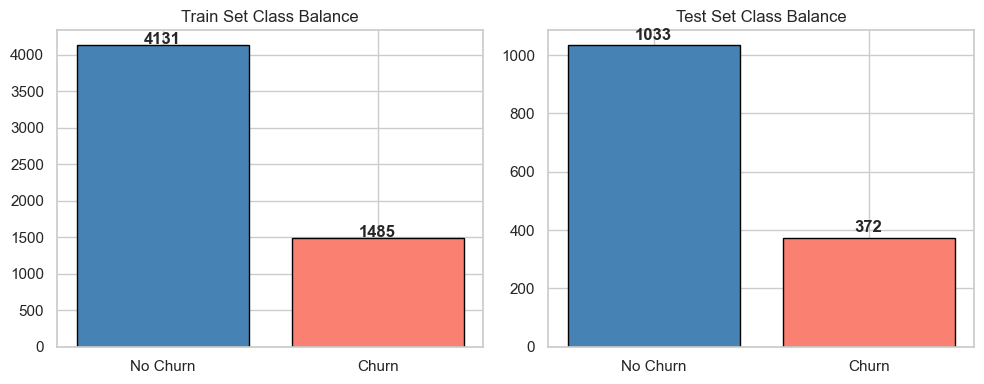

In [2]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train : {X_train.shape} | Churn rate: {y_train.mean():.3f}')
print(f'Test  : {X_test.shape}  | Churn rate: {y_test.mean():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, y_split) in zip(axes, [('Train', y_train), ('Test', y_test)]):
    counts = y_split.value_counts()
    ax.bar(['No Churn', 'Churn'], counts.values, color=['steelblue', 'salmon'], edgecolor='black')
    ax.set_title(f'{name} Set Class Balance')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'class_balance.png')
plt.show()

## 3. SMOTE — Handle Class Imbalance

In [3]:
sm = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print(f'Before: {X_train.shape[0]} samples | Churn: {y_train.mean():.1%}')
print(f'After : {X_train_res.shape[0]} samples | Churn: {y_train_res.mean():.1%}')

Before: 5616 samples | Churn: 26.4%
After : 8262 samples | Churn: 50.0%


## 4. Define Models

In [4]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=5,
        random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        num_leaves=31, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
}
print('Models:', list(models.keys()))

Models: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']


## 5. Train & Cross-Validate

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}
os.makedirs('../models', exist_ok=True)

for name, model in models.items():
    print(f'\n🔄 Training: {name}')
    model.fit(X_train_res, y_train_res)
    cv_auc = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_f1  = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring='f1', n_jobs=-1)
    results[name] = {
        'model': model,
        'cv_auc_mean': cv_auc.mean(), 'cv_auc_std': cv_auc.std(),
        'cv_f1_mean' : cv_f1.mean(),  'cv_f1_std' : cv_f1.std(),
    }
    print(f'   CV AUC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
    print(f'   CV F1  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
    safe = name.lower().replace(' ', '_')
    joblib.dump(model, f'../models/{safe}.pkl')
    print(f'   ✅ Saved: models/{safe}.pkl')


🔄 Training: Logistic Regression
   CV AUC : 0.9149 ± 0.0085
   CV F1  : 0.8378 ± 0.0102
   ✅ Saved: models/logistic_regression.pkl

🔄 Training: Random Forest
   CV AUC : 0.9057 ± 0.0079
   CV F1  : 0.8334 ± 0.0084
   ✅ Saved: models/random_forest.pkl

🔄 Training: XGBoost
   CV AUC : 0.9194 ± 0.0086
   CV F1  : 0.8509 ± 0.0078
   ✅ Saved: models/xgboost.pkl

🔄 Training: LightGBM
   CV AUC : 0.9186 ± 0.0084
   CV F1  : 0.8512 ± 0.0089
   ✅ Saved: models/lightgbm.pkl


## 6. Leaderboard


===== MODEL LEADERBOARD =====


,Model,CV AUC,CV F1
1,XGBoost,0.9194 ± 0.0086,0.8509 ± 0.0078
2,LightGBM,0.9186 ± 0.0084,0.8512 ± 0.0089
3,Logistic Regression,0.9149 ± 0.0085,0.8378 ± 0.0102
4,Random Forest,0.9057 ± 0.0079,0.8334 ± 0.0084


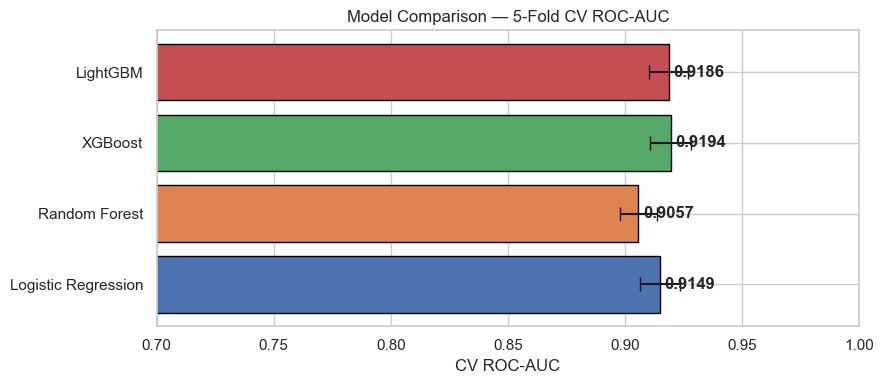

In [6]:
lb = pd.DataFrame([{
    'Model': n, 'AUC (raw)': r['cv_auc_mean'],
    'CV AUC': f"{r['cv_auc_mean']:.4f} ± {r['cv_auc_std']:.4f}",
    'CV F1' : f"{r['cv_f1_mean']:.4f} ± {r['cv_f1_std']:.4f}"
} for n, r in results.items()]).sort_values('AUC (raw)', ascending=False).drop(columns='AUC (raw)').reset_index(drop=True)
lb.index += 1
print('\n===== MODEL LEADERBOARD =====')
display(lb)

names = list(results.keys())
means = [results[n]['cv_auc_mean'] for n in names]
stds  = [results[n]['cv_auc_std']  for n in names]
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(names, means, xerr=stds, color=['#4C72B0','#DD8452','#55A868','#C44E52'], edgecolor='black', capsize=5)
ax.set_xlabel('CV ROC-AUC')
ax.set_title('Model Comparison — 5-Fold CV ROC-AUC')
ax.set_xlim(0.7, 1.0)
for bar, mean in zip(bars, means):
    ax.text(mean + 0.002, bar.get_y() + bar.get_height()/2, f'{mean:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'model_comparison_auc.png')
plt.show()

## 7. Save Train/Test Split

In [8]:
joblib.dump((X_train, X_test, y_train, y_test), '../models/train_test_split.pkl')
print('✅ Saved: models/train_test_split.pkl')


✅ Saved: models/train_test_split.pkl
